# Time Series Analysis of Infectious Disease Data (Complete Notes)

This notebook provides a **complete understanding of time series analysis** using real COVID-19 data.

## What you will learn:
- Trend, Seasonality, Noise
- Decomposition methods
- Forecasting models (Regression, ETS, ARIMA, SARIMA)
- Residual diagnostics
- Model comparison & validation

---

## Key Focus:
For each concept, we explain:
1. Why it is useful
2. Mathematical formulation
3. Practical intuition
4. Advantages and limitations

## 1. Data Preparation

### Why is this important?

Raw epidemiological data is usually **cumulative** (total deaths, cases).

But modeling requires **incremental data (daily changes)**:
- Trend becomes visible
- Seasonality becomes visible
- Models become meaningful

---

### Mathematical Concept

We convert cumulative data:

$Y_t = X_t - X_{t-1}$

Where:
- $ X_t $: cumulative deaths
- $ Y_t $: daily deaths

---

### Insight
Without this step:
- Data is always increasing
- Models fail to capture dynamics

In [ ]:
import pandas as pd
import numpy as np

# Load dataset (upload file in Colab first)
df = pd.read_csv('state_long.csv')

df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(['State', 'DATE'])

# Convert cumulative → daily
df['Y.Death'] = df.groupby('State')['Death'].diff()

df = df.dropna()

# Select Florida
florida = df[df['State'] == 'Florida'].copy()

florida.head()

,State,Region,Division,pop,DATE,Infected,Death,Y.Death
3103,Florida,South,South Atlantic,21299325,2020-01-23,0,0,0.0
3102,Florida,South,South Atlantic,21299325,2020-01-24,0,0,0.0
3101,Florida,South,South Atlantic,21299325,2020-01-25,0,0,0.0
3100,Florida,South,South Atlantic,21299325,2020-01-26,0,0,0.0
3099,Florida,South,South Atlantic,21299325,2020-01-27,0,0,0.0


## 2. Time Series Visualization

### Why?

Visualization helps identify:
- Trend
- Seasonality
- Noise
- Structural breaks

---

### Concepts

A time series is composed of:
$Y_t = Trend + Seasonality + Noise$


---

### Insight

For COVID data:
- Trend → waves
- Seasonality → weekly reporting pattern
- Noise → random fluctuations

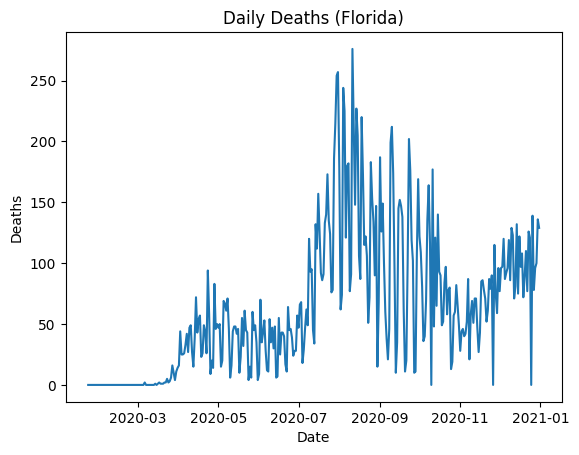

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(florida['DATE'], florida['Y.Death'])
plt.title("Daily Deaths (Florida)")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.show()

## 3. Trend

### Why?

Trend captures **long-term movement**:
- Pandemic waves
- Growth/decline phases

---

### Model

$Y_t = \beta_0 + \beta_1 t + \epsilon_t$

---

### Intuition

- Linear trend → steady increase/decrease
- Polynomial → curved trends

---

### Advantages
- Simple and interpretable
- Easy to implement

### Limitations
- Cannot capture seasonality
- Poor for nonlinear behavior

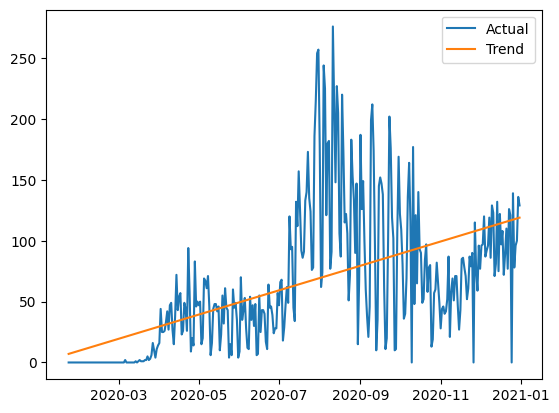

In [ ]:
import statsmodels.api as sm

florida['t'] = np.arange(len(florida))

X = sm.add_constant(florida['t'])
model_trend = sm.OLS(florida['Y.Death'], X).fit()

florida['trend'] = model_trend.fittedvalues

plt.figure()
plt.plot(florida['DATE'], florida['Y.Death'], label='Actual')
plt.plot(florida['DATE'], florida['trend'], label='Trend')
plt.legend()
plt.show()

## 4. Seasonality

### Why?

Real-world data often repeats patterns:
- Weekly cycles (COVID reporting)
- Monthly/annual cycles

---

### Mathematical Definition

$s_t = s_{t+d}$

where $d = 7$ (weekly)

---

### Insight

COVID data:
- Low on weekends
- High mid-week

---

### Advantages
- Improves forecasting accuracy
- Captures periodic behavior

### Limitation
- Requires known period

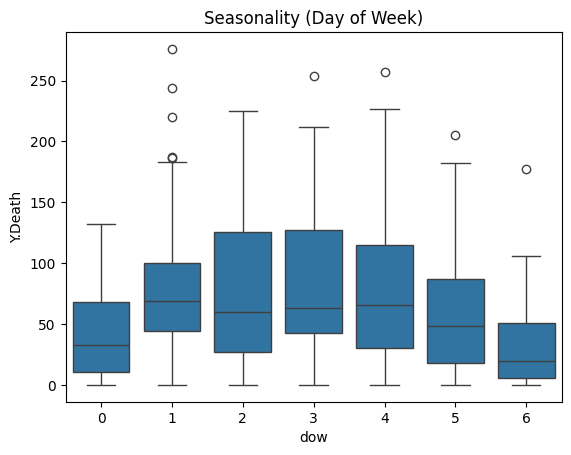

In [ ]:
florida['dow'] = florida['DATE'].dt.dayofweek

import seaborn as sns

sns.boxplot(x=florida['dow'], y=florida['Y.Death'])
plt.title("Seasonality (Day of Week)")
plt.show()

## 5. Moving Average

### Why?

Removes noise and reveals trend.

---

### Formula

$\hat{m}_t = \frac{1}{2q+1} \sum_{k=-q}^{q} Y_{t-k}$

---

### Insight

- Small window → noisy but detailed
- Large window → smooth but biased

---

### Bias-Variance Tradeoff

| Window | Effect |
|------|-------|
| Small | Low bias, high variance |
| Large | High bias, low variance |

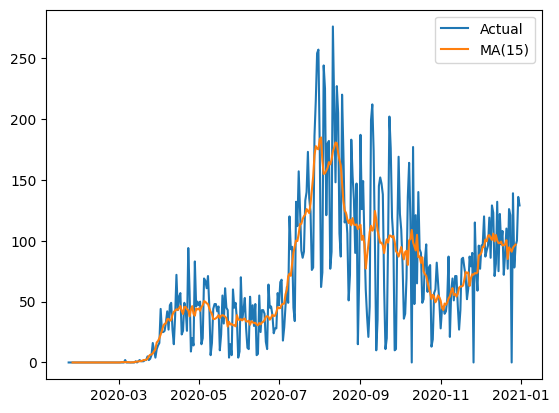

In [ ]:
florida['MA7'] = florida['Y.Death'].rolling(7, center=True).mean()

plt.figure()
plt.plot(florida['DATE'], florida['Y.Death'], label='Actual')
plt.plot(florida['DATE'], florida['MA7'], label='MA(15)')
plt.legend()
plt.show()

# Time Series Decomposition and Forecasting (US COVID Data)

This notebook implements concepts from:

- Time Series Decomposition (Section 9.3)
- Forecasting Methods (Section 9.4)

using **US COVID (Florida) daily death data**.

---

## Objectives

- Understand trend, seasonality, noise
- Apply smoothing techniques
- Perform decomposition (STL)
- Implement forecasting models
- Interpret real-world results

## 1. Polynomial Regression (Trend Estimation)

###  Model
$Y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \cdots + \beta_d t^d + Z_t$

### Meaning of terms

- $Y_t$: daily deaths at time \(t\)  
- $t$: time index  
- $\beta_i$: coefficients (trend parameters)  
- $Z_t$: random noise (IID, mean 0, variance σ²)

---

### Why?

To estimate **smooth long-term trend**

---




### Advantages
- Simple, interpretable  

### Disadvantages
- Cannot capture seasonality or correlation  

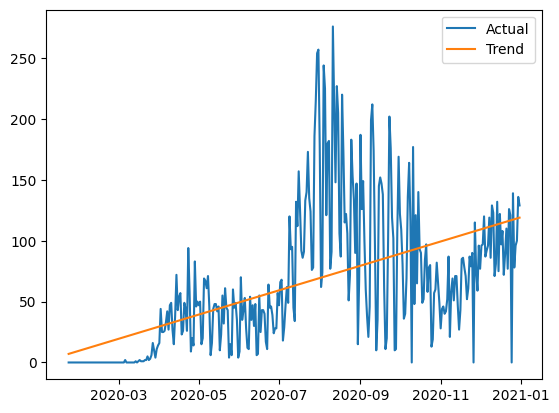

In [ ]:
import statsmodels.api as sm

florida['t'] = np.arange(len(florida))

X = sm.add_constant(florida['t'])
model = sm.OLS(florida['Y.Death'], X).fit()

florida['trend'] = model.fittedvalues

plt.plot(florida['DATE'], florida['Y.Death'], label='Actual')
plt.plot(florida['DATE'], florida['trend'], label='Trend')
plt.legend()
plt.show()

### Interpretation

- Captures only trend → misses seasonal pattern  

## 1. Polynomial Regression with Seasonality

### Model
$Y_t = \beta_0 + \beta_1 t + \beta_2 t^2 + \sum_{i=1}^{6} \gamma_i D_i + Z_t$

### Meaning

- \(Y_t\): observed deaths at time \(t\)  
- \(t\): time index  
- \(t^2\): curvature (pandemic waves)  
- \(D_i\): seasonal dummy variables (day of week)  
- \(\gamma_i\): seasonal coefficients  
- \(Z_t\): random noise (IID, mean 0, variance σ²)

---

### Interpretation (Fig 9.7)

- Top: only trend → misses weekly variation  
- Bottom: with seasonality → better fit  

---

### Advantages
- Captures trend + seasonality  
- Interpretable  

### Disadvantages
- Cannot capture autocorrelation  
- Poor long-term forecasts  

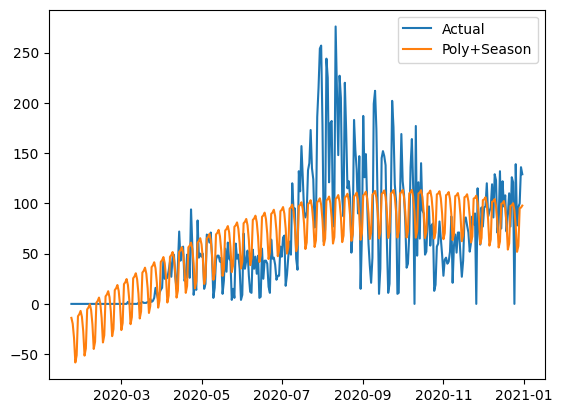

In [ ]:
import statsmodels.api as sm

florida['t'] = np.arange(len(florida))
florida['t2'] = florida['t']**2
florida['dow'] = florida['DATE'].dt.dayofweek

dummies = pd.get_dummies(florida['dow'], drop_first=True, dtype=float)

X = pd.concat([florida[['t','t2']], dummies], axis=1)
X = sm.add_constant(X)

y = florida['Y.Death'].astype(float)

model = sm.OLS(y, X).fit()
florida['fit_poly'] = model.fittedvalues

plt.plot(florida['DATE'], y, label='Actual')
plt.plot(florida['DATE'], florida['fit_poly'], label='Poly+Season')
plt.legend()
plt.show()

### Interpretation

- plot → includes seasonality → better fit  

Conclusion: Trend alone is insufficient

## 2. Moving Average

### Model
$\hat{m}_t = \frac{1}{2q+1} \sum_{k=-q}^{q} Y_{t-k}$

### Meaning

- \(Y_{t-k}\): past observations  
- \(q\): window size parameter  
- \(\hat{m}_t\): smoothed trend  

---

### Interpretation (Fig 9.8)

- MA(5) → follows data closely  
- MA(15) → smoother but loses peaks  

---

### Bias–Variance Tradeoff

- Small window → low bias, high variance  
- Large window → high bias, low variance  

---

### Advantages
- Simple smoothing  

### Disadvantages
- Lag and distortion  

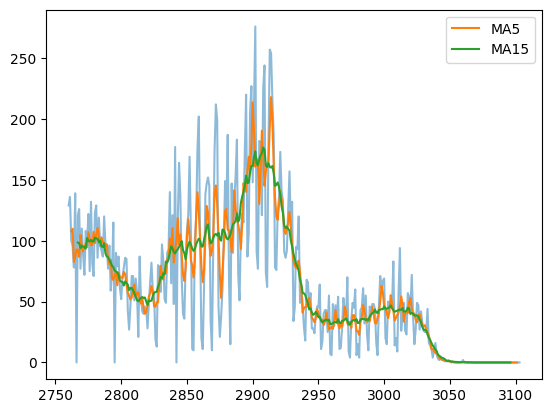

In [ ]:
florida['MA5'] = florida['Y.Death'].rolling(5, center=True).mean()
florida['MA15'] = florida['Y.Death'].rolling(15, center=True).mean()

plt.plot(florida['Y.Death'], alpha=0.5)
plt.plot(florida['MA5'], label='MA5')
plt.plot(florida['MA15'], label='MA15')
plt.legend()
plt.show()

## 3. Exponential Smoothing

### Model

$\hat{m}_t = \alpha Y_t + (1-\alpha)\hat{m}_{t-1}$

---

### Meaning

- \(Y_t\): current value  
- \(\hat{m}_{t-1}\): previous estimate  
- \(\alpha\): smoothing parameter  

---

### Interpretation (Fig 9.9)

- Simple model → misses structure  
- With trend & seasonality → accurate  

---

### Advantages
- Adaptive  

### Disadvantages
- Needs tuning  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


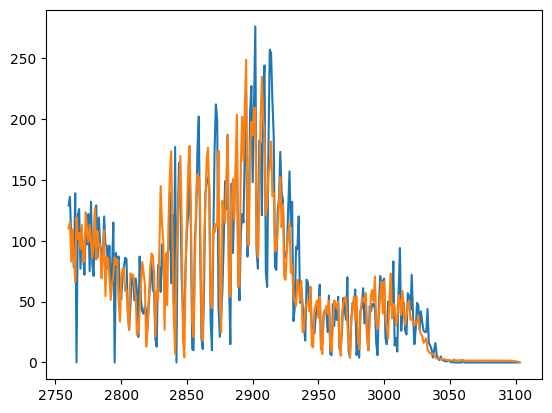

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets = ExponentialSmoothing(
    florida['Y.Death'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

florida['ETS'] = ets.fittedvalues

plt.plot(florida['Y.Death'])
plt.plot(florida['ETS'])
plt.show()

## 4. Seasonal Component

### Definition

$s_t = s_{t+d}$

---

### Meaning

- \(s_t\): seasonal effect  
- \(d\): period (7 days)

---

### Why?

Captures weekly reporting pattern  

---

### Limitation
- Assumes fixed periodicity  

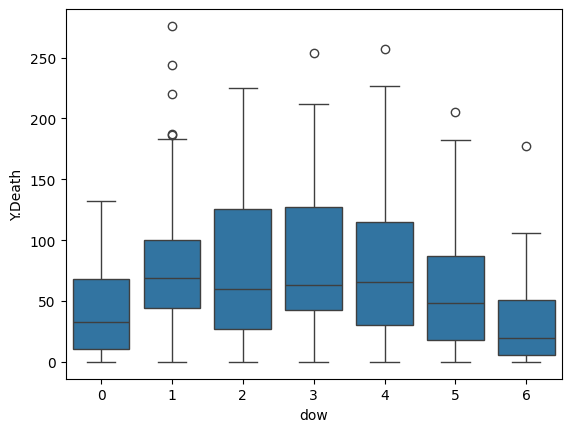

In [ ]:
florida['dow'] = florida['DATE'].dt.dayofweek

import seaborn as sns
sns.boxplot(x=florida['dow'], y=florida['Y.Death'])
plt.show()

## 5. STL Decomposition

### Model

$Y_t = T_t + S_t + R_t$

---

### Meaning

- \(T_t\): trend  
- \(S_t\): seasonal  
- \(R_t\): residual  

---

### Interpretation (Fig 9.11 & 9.12)

- Trend → pandemic waves  
- Season → weekly oscillation  
- Residual → noise  

---

### Window Insight

- Small window → flexible  
- Large window → smooth  

---

### Advantages
- Robust  

### Disadvantages
- Computational cost  

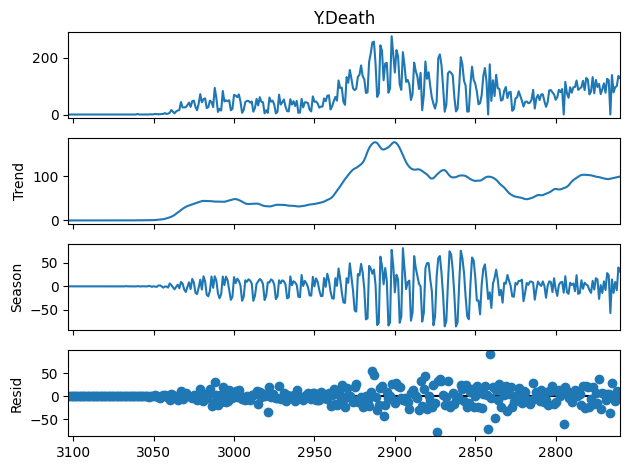

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(florida['Y.Death'], period=7)
res = stl.fit()
res.plot()
plt.show()

## 6. Average Method

### Model

$Y_t = \mu + Z_t$

---

### Meaning

- \(\mu\): mean  
- \(Z_t\): noise  

---

### Forecast
$\hat{Y}_{n+h} = \frac{1}{n}\sum Y_t$

---

### Interpretation (Fig 9.13)

Flat forecast → unrealistic  

---

### Limitation
Ignores structure  

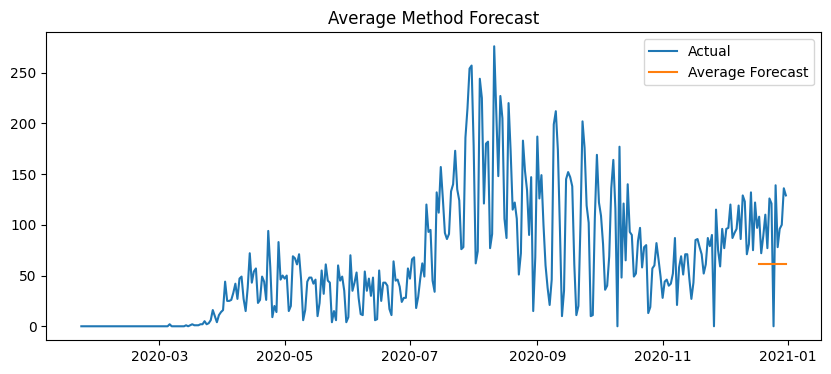

In [ ]:


# Train-Test Split (last 14 days for forecasting)
train = florida.iloc[:-14]
test = florida.iloc[-14:]


# Average Method
# Model: Y_t = μ + Z_t

mean_value = train['Y.Death'].mean()

forecast_mean = [mean_value]*14

# Plot
plt.figure(figsize=(10,4))
plt.plot(florida['DATE'], florida['Y.Death'], label='Actual')
plt.plot(test['DATE'], forecast_mean, label='Average Forecast')
plt.legend()
plt.title("Average Method Forecast")
plt.show()

## 7. Random Walk

### Model
$Y_t = Y_{t-1} + Z_t$

---

### Meaning

- \(Y_{t-1}\): previous value  
- \(Z_t\): noise  

---

### Forecast
$\hat{Y}_{n+h} = Y_n$

---

### Interpretation (Fig 9.13)

Flat but better than mean  

---

### Limitation
No trend  

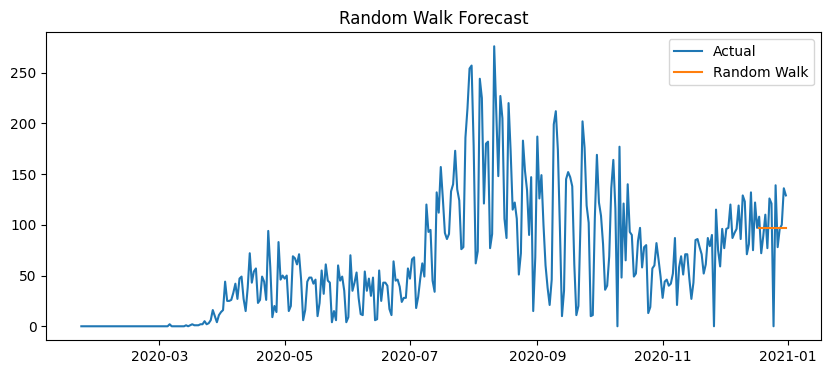

In [ ]:
# Random Walk (Naive)
# Model: Y_t = Y_{t-1} + Z_t

last_value = train['Y.Death'].iloc[-1]

forecast_rw = [last_value]*14

# Plot
plt.figure(figsize=(10,4))
plt.plot(florida['DATE'], florida['Y.Death'], label='Actual')
plt.plot(test['DATE'], forecast_rw, label='Random Walk')
plt.legend()
plt.title("Random Walk Forecast")
plt.show()

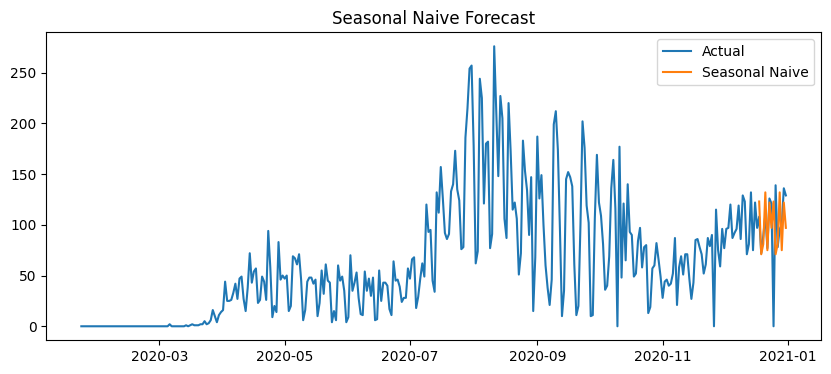

In [ ]:
#  Seasonal Naive
# Model: Y_t = Y_{t-7}

seasonal_period = 7

last_week = train['Y.Death'].iloc[-seasonal_period:].values

# Repeat pattern
forecast_snaive = np.tile(last_week, 2)[:14]

# Plot
plt.figure(figsize=(10,4))
plt.plot(florida['DATE'], florida['Y.Death'], label='Actual')
plt.plot(test['DATE'], forecast_snaive, label='Seasonal Naive')
plt.legend()
plt.title("Seasonal Naive Forecast")
plt.show()

## 9. Random Walk with Drift

### Model
$Y_t = c + Y_{t-1} + Z_t$

---

### Meaning

- \(c\): drift (average change)  
- \(Y_{t-1}\): previous value  
- \(Z_t\): noise  

---

### Forecast
$\hat{Y}_{n+h} = Y_n + h\frac{Y_n - Y_1}{n-1}$

---

### Interpretation (Fig 9.13)

Linear forecast  

---

### Advantage
Captures trend  

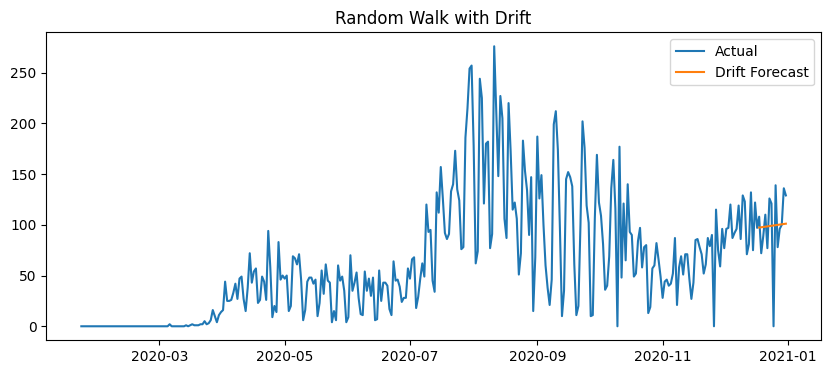

In [ ]:
# Random Walk with Drift
# Model: Y_t = c + Y_{t-1} + Z_t

n = len(train)

drift = (train['Y.Death'].iloc[-1] - train['Y.Death'].iloc[0])/(n-1)

forecast_drift = [
    train['Y.Death'].iloc[-1] + (h+1)*drift for h in range(14)
]

# Plot
plt.figure(figsize=(10,4))
plt.plot(florida['DATE'], florida['Y.Death'], label='Actual')
plt.plot(test['DATE'], forecast_drift, label='Drift Forecast')
plt.legend()
plt.title("Random Walk with Drift")
plt.show()

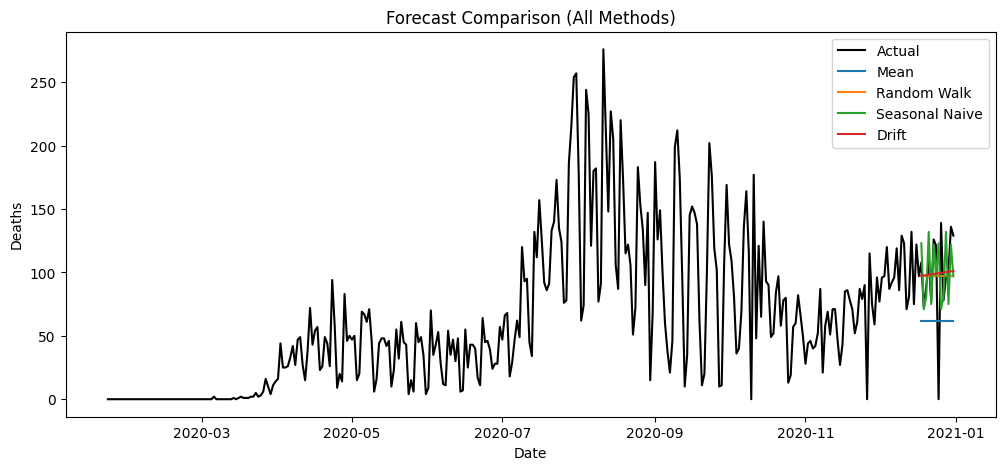

In [ ]:
# Combined Comparison (like Fig 9.14)

plt.figure(figsize=(12,5))

# Actual
plt.plot(florida['DATE'], florida['Y.Death'], label='Actual', color='black')

# Forecasts
plt.plot(test['DATE'], forecast_mean, label='Mean')
plt.plot(test['DATE'], forecast_rw, label='Random Walk')
plt.plot(test['DATE'], forecast_snaive, label='Seasonal Naive')
plt.plot(test['DATE'], forecast_drift, label='Drift')

plt.legend()
plt.title("Forecast Comparison (All Methods)")
plt.xlabel("Date")
plt.ylabel("Deaths")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}")

print("Forecast Accuracy:\n")

evaluate(test['Y.Death'], forecast_mean, "Mean")
evaluate(test['Y.Death'], forecast_rw, "Random Walk")
evaluate(test['Y.Death'], forecast_snaive, "Seasonal Naive")
evaluate(test['Y.Death'], forecast_drift, "Drift")

Forecast Accuracy:

Mean: MAE=45.94, RMSE=50.83
Random Walk: MAE=25.93, RMSE=34.73
Seasonal Naive: MAE=26.93, RMSE=41.64
Drift: MAE=25.44, RMSE=34.44


## 10. Forecast Distribution

### Example

Random Walk:

$\hat{Y}_{n+h} \sim N(Y_n, h\sigma^2)$

---

### Meaning

- Mean = forecast  
- Variance increases with horizon  

---

### Insight

Uncertainty grows over time  

##  11. Prediction Interval

### Formula
$\hat{Y}_{n+h} \pm 1.96\sigma_h$

---

### Meaning

Range of possible values (95%)  

---

### Interpretation

Wide interval → uncertain forecast  

## Final Understanding

Time series = Trend + Seasonality + Noise

---

### Best methods:

- Trend → regression / MA  
- Seasonality → STL  
- Forecast → seasonal naive / ETS  

---

### Key Insight

No single model is perfect  
Always compare models  

# Residual Diagnostics, ARIMA & Model Evaluation (US COVID Data)

This notebook covers:

- Residual diagnostics
- Forecast accuracy measures
- Differencing & stationarity
- AR, MA, ARMA, ARIMA
- SARIMA models
- Model comparison (ETS vs ARIMA)
- Time series cross-validation

Dataset: Florida COVID daily deaths

## 1. Residual Diagnostics

### Residual Definition

$e_t = Y_t - \hat{Y}_t$

### Meaning

- \(Y_t\): actual value  
- \(\hat{Y}_t\): fitted value  
- \(e_t\): residual (error)

---

### Why?

Check if model captured all information  

---

### Good Residual Properties

1. No autocorrelation  
2. Mean = 0  
3. Constant variance  
4. Normal distribution  

---

### Interpretation (Fig 9.15 & 9.16)

- Random scatter → good model  
- Pattern → model missing structure  

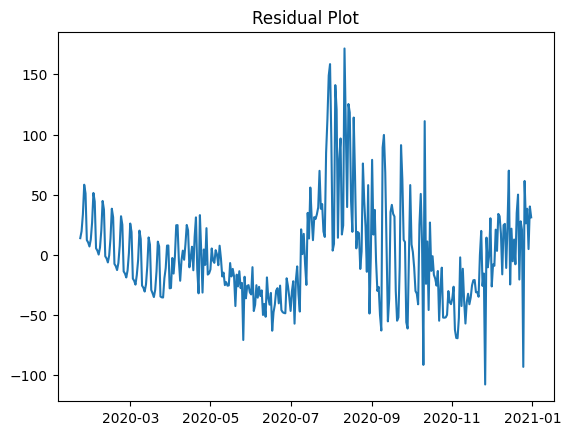

In [ ]:
# Fit polynomial + seasonality model (from earlier)
import statsmodels.api as sm

florida['t'] = np.arange(len(florida))
florida['t2'] = florida['t']**2
florida['dow'] = florida['DATE'].dt.dayofweek

dummies = pd.get_dummies(florida['dow'], drop_first=True, dtype=float)

X = pd.concat([florida[['t','t2']], dummies], axis=1)
X = sm.add_constant(X)

y = florida['Y.Death'].astype(float)

model = sm.OLS(y, X).fit()

# Residuals
residuals = model.resid

# Plot residuals
plt.plot(florida['DATE'], residuals)
plt.title("Residual Plot")
plt.show()

## Residual Diagnostics (ACF + Histogram)

### Interpretation (Fig 9.16)

- ACF near zero → no correlation  
- Histogram bell-shaped → normal  

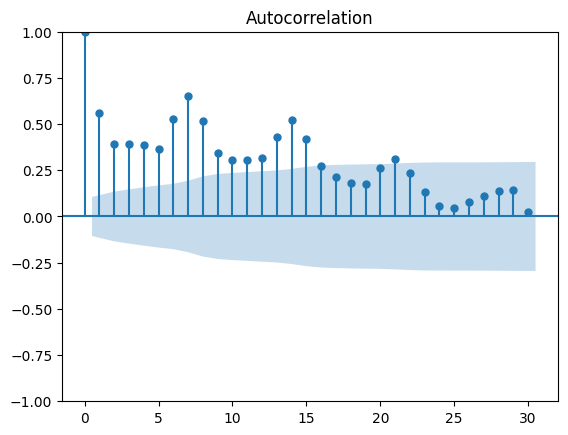

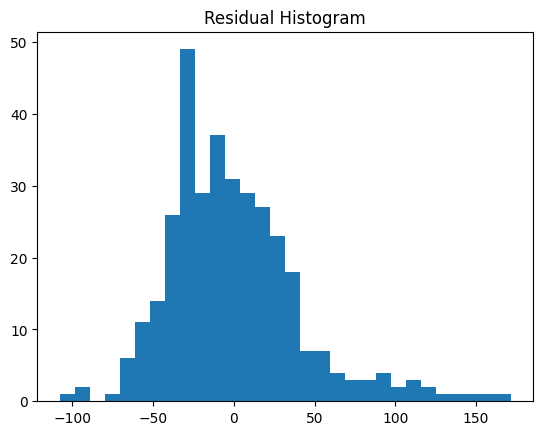

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=30)
plt.show()

plt.hist(residuals, bins=30)
plt.title("Residual Histogram")
plt.show()

##  2. Forecast Accuracy

### Error Definition
$e_{n+h} = Y_{n+h} - \hat{Y}_{n+h|n}$

---
$e_t>0$: Underestimation (forecast too low)


$ e_t < 0$: Overestimation (forecast too high)

$e_t=0$: Perfect forecast

### Measures

MAE:

$\frac{1}{n}\sum |e_t|$

### Interpretation
- Average magnitude of errors (ignores sign)
- Same units as data (e.g., deaths, cases)
- Measures average deviation from actual values

### Advantages
- Easy to understand and interpret
- Robust to outliers (compared to RMSE)
- Linear penalty → all errors treated equally

### Disadvantages
- Does not heavily penalize large errors
- Not differentiable at zero (issue in optimization contexts)
- Cannot capture variance of errors

RMSE:

$\sqrt{\frac{1}{n}\sum e_t^2}$

### Interpretation
- Square root of average squared errors
- Penalizes large errors more heavily
- Same units as data

### Advantages
- Sensitive to large errors (good for risk-sensitive problems)
- Widely used in ML and forecasting
- Differentiable → useful for optimization

### Disadvantages
- Highly sensitive to outliers
- Can be misleading if few large errors dominate
- Less intuitive than MAE

MAPE:

$\frac{1}{n}\sum \left|\frac{100e_t}{Y_t}\right|$

### Interpretation
- Error expressed in percentage
- Scale-independent → useful for comparison across datasets
- Example: MAPE = 10% → forecasts are off by 10% on average

### Advantages
- Easy to interpret (percentage error)
- Scale-free → compare across models/data
- Common in business and epidemiology

### Disadvantages
- Undefined when $Y_t=0$ (common in COVID early data ⚠️)
- Biased when values are very small
- Over-penalizes small denominators
---

### Meaning

- Measures how good forecast is  

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# train-test split
train = florida.iloc[:-14]
test = florida.iloc[-14:]

# example forecast (naive)
forecast = [train['Y.Death'].iloc[-1]]*14

mae = mean_absolute_error(test['Y.Death'], forecast)
rmse = np.sqrt(mean_squared_error(test['Y.Death'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 25.928571428571427
RMSE: 34.72853910793584


# ARIMA & SARIMA Models (US COVID Data)

This part covers:

- Differencing & stationarity
- AR, MA, ARMA models
- ARIMA model
- SARIMA model
- Model selection (AIC, BIC)
- Forecasting

Dataset: Florida COVID daily deaths

## 1. Differencing

## Backshift Operator
$B^k X_t = X_{t-k}$

### Meaning

- \(B\): shift operator  
- \(X_t\): time series  

---

###  First Difference
$(1-B)X_t = X_t - X_{t-1}$

### Meaning

- Removes trend  

---

### Seasonal Difference

$(1-B^d)X_t = X_t - X_{t-d}$

- \(d\): seasonal lag (7 days)

---

### Interpretation (Fig 9.19)

From the figure:

- Top left → cumulative deaths (non-stationary)
- Top right → daily deaths (first difference)
- Bottom left → weekly difference
- Bottom right → stationary series

Differencing removes trend & seasonality

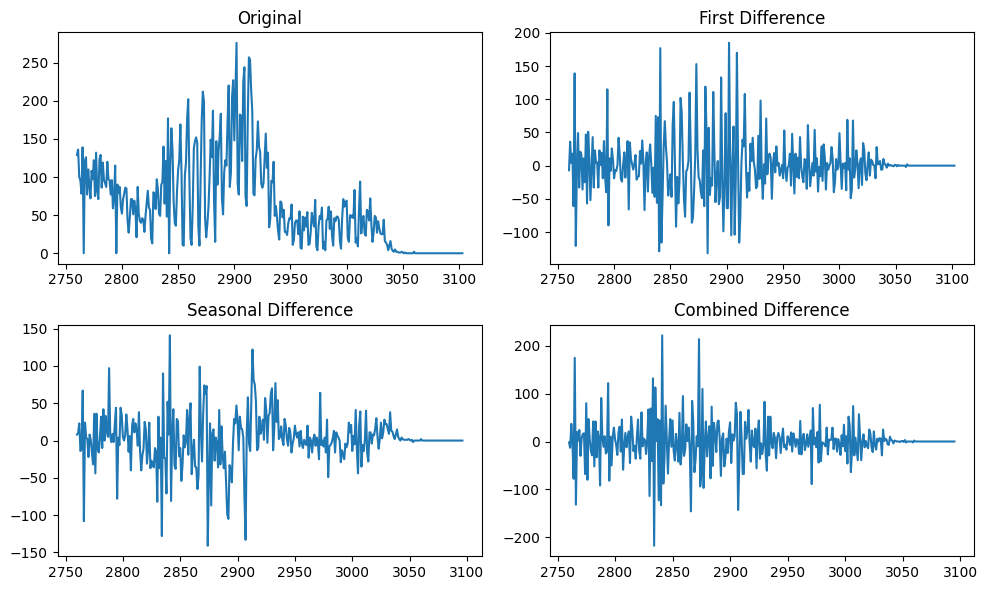

In [ ]:
# Differencing using Florida data

florida['diff1'] = florida['Y.Death'].diff()
florida['diff7'] = florida['Y.Death'].diff(7)
florida['diff1_7'] = florida['diff1'].diff(7)

plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.plot(florida['Y.Death'])
plt.title("Original")

plt.subplot(2,2,2)
plt.plot(florida['diff1'])
plt.title("First Difference")

plt.subplot(2,2,3)
plt.plot(florida['diff7'])
plt.title("Seasonal Difference")

plt.subplot(2,2,4)
plt.plot(florida['diff1_7'])
plt.title("Combined Difference")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

def plot_forecast(train, test, forecast, title):
    plt.figure(figsize=(10,4))
    plt.plot(train['DATE'], train['Y.Death'], label='Train')
    plt.plot(test['DATE'], test['Y.Death'], label='Test')
    plt.plot(test['DATE'], forecast, label='Forecast')
    plt.legend()
    plt.title(title)
    plt.show()

## 2. Autoregressive Model AR(p)

### Model

$X_t = \phi_1 X_{t-1} + \cdots + \phi_p X_{t-p} + Z_t$

---

### Meaning

- \(X_t\): current value  
- \(X_{t-1}\): past value  
- \(\phi_i\): coefficients  
- \(Z_t\): white noise  

---

### Interpretation

- Depends on past values  

---

### ACF/PACF

- PACF cuts off at lag p  
- ACF decays  

---

### Advantage
- Captures persistence  

### Disadvantage
- Needs stationarity  

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_ar = ARIMA(florida['Y.Death'], order=(2,0,0)).fit()
print(model_ar.summary())

                               SARIMAX Results                                
Dep. Variable:                Y.Death   No. Observations:                  344
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1756.252
Date:                Tue, 14 Apr 2026   AIC                           3520.504
Time:                        06:02:38   BIC                           3535.867
Sample:                             0   HQIC                          3526.623
                                - 344                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         63.0017     11.694      5.388      0.000      40.082      85.921
ar.L1          0.6676      0.047     14.181      0.000       0.575       0.760
ar.L2          0.0826      0.041      1.994      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

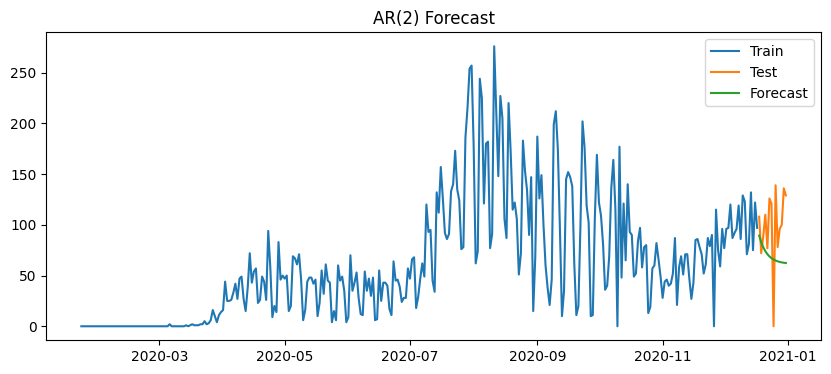

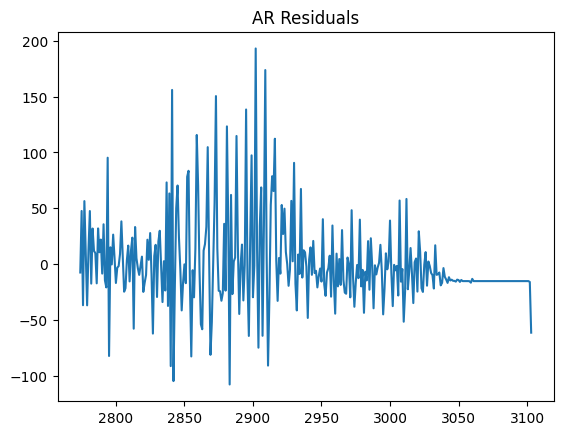

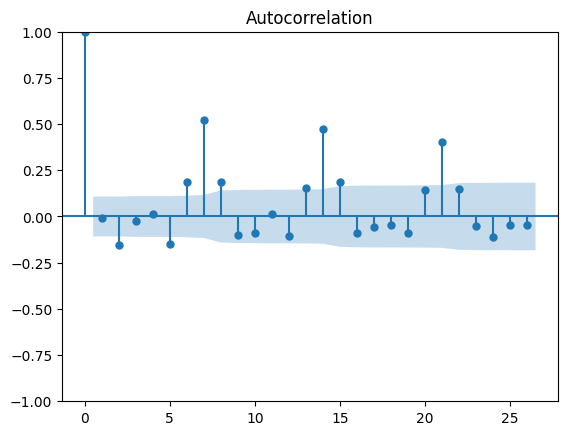

AR → MAE: 39.79, RMSE: 46.58


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf

# AR(p)
model_ar = ARIMA(train['Y.Death'], order=(2,0,0)).fit()

# Forecast
forecast_ar = model_ar.forecast(14)

# Plot
plot_forecast(train, test, forecast_ar, "AR(2) Forecast")

# Residual diagnostics
residuals = model_ar.resid

plt.plot(residuals)
plt.title("AR Residuals")
plt.show()

plot_acf(residuals)
plt.show()

# Accuracy
evaluate_model(test['Y.Death'], forecast_ar, "AR")

## 3. Moving Average Model MA(q)

### Model

$X_t = Z_t + \theta_1 Z_{t-1} + \cdots + \theta_q Z_{t-q}$

---

### Meaning

- \(Z_t\): noise  
- \(\theta_i\): coefficients  

---

### Interpretation

- Depends on past shocks  

---

### ACF/PACF

- ACF cuts off  
- PACF decays  

---

### Advantage
- Models shocks  

### Disadvantage
- Less intuitive  

In [ ]:
model_ma = ARIMA(florida['Y.Death'], order=(0,0,2)).fit()
print(model_ma.summary())

                               SARIMAX Results                                
Dep. Variable:                Y.Death   No. Observations:                  344
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1779.650
Date:                Tue, 14 Apr 2026   AIC                           3567.300
Time:                        06:03:21   BIC                           3582.662
Sample:                             0   HQIC                          3573.419
                                - 344                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         62.9994      6.082     10.359      0.000      51.079      74.919
ma.L1          0.7330      0.038     19.269      0.000       0.658       0.808
ma.L2          0.3247      0.047      6.888      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

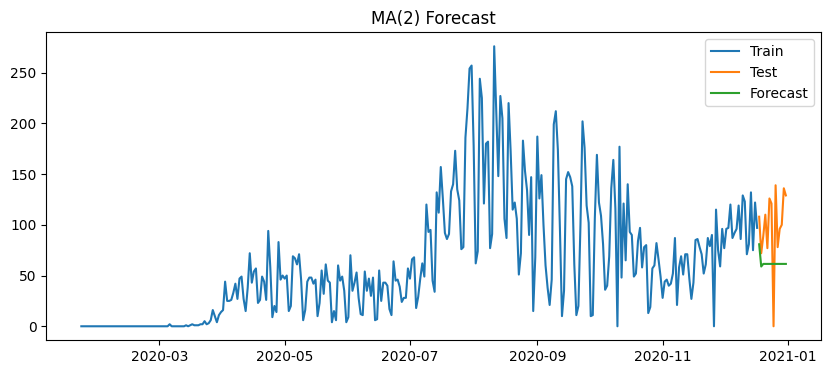

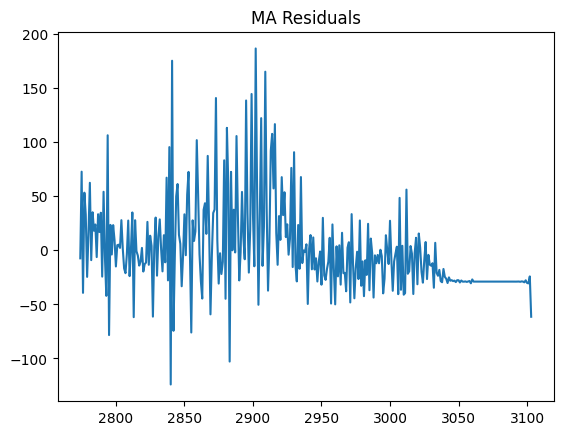

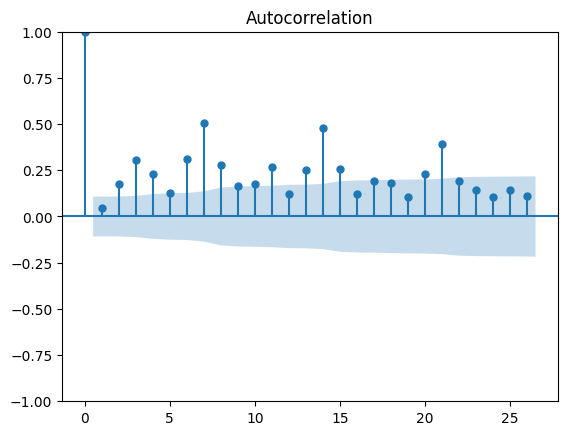

MA → MAE: 44.75, RMSE: 49.87


In [ ]:
# MA(q)
model_ma = ARIMA(train['Y.Death'], order=(0,0,2)).fit()

forecast_ma = model_ma.forecast(14)

plot_forecast(train, test, forecast_ma, "MA(2) Forecast")

# Residuals
residuals = model_ma.resid

plt.plot(residuals)
plt.title("MA Residuals")
plt.show()

plot_acf(residuals)
plt.show()

evaluate_model(test['Y.Death'], forecast_ma, "MA")

## 🔷 4. ARMA(p,q)

### Model

$\phi(B)X_t = \theta(B)Z_t$

---

### Expanded

$X_t = \phi_1 X_{t-1} + \cdots + Z_t + \theta_1 Z_{t-1}$

---

### Meaning

- Combines AR + MA  

---

### Advantage
- Flexible  

### Disadvantage
- Requires stationarity  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

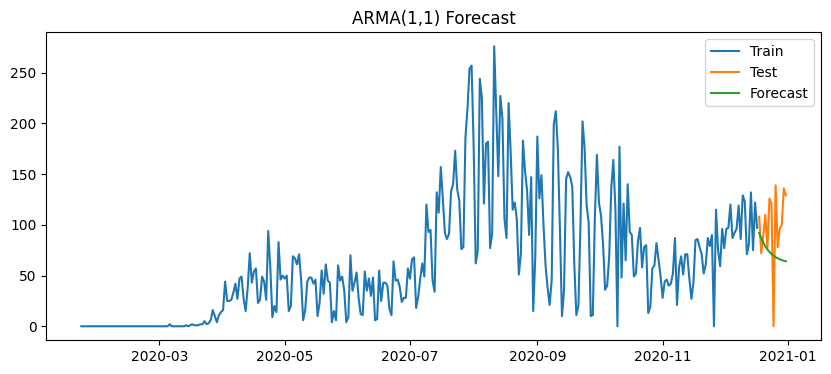

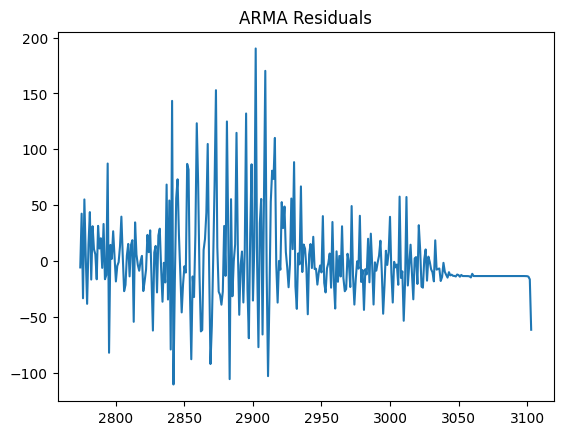

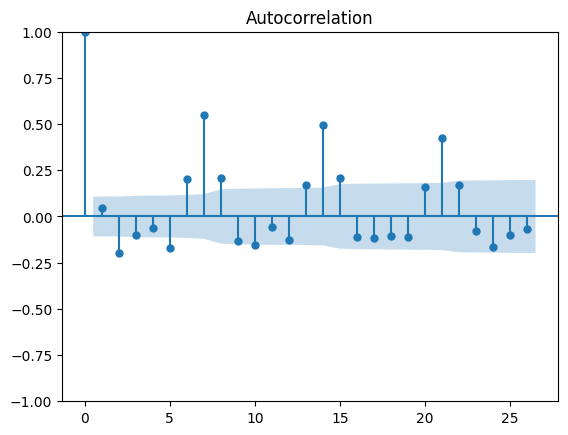

ARMA → MAE: 37.46, RMSE: 44.83


In [ ]:
# ARMA(p,q)
model_arma = ARIMA(train['Y.Death'], order=(1,0,1)).fit()

forecast_arma = model_arma.forecast(14)

plot_forecast(train, test, forecast_arma, "ARMA(1,1) Forecast")

# Residuals
residuals = model_arma.resid

plt.plot(residuals)
plt.title("ARMA Residuals")
plt.show()

plot_acf(residuals)
plt.show()

evaluate_model(test['Y.Death'], forecast_arma, "ARMA")

## 5. ARIMA(p,d,q)

### Model

$(1-B)^d Y_t = X_t \sim ARMA(p,q)%

---

### Meaning

- \(d\): differencing order  
- \(p\): AR order  
- \(q\): MA order  

---

### Why?

Handles non-stationary data  

---

### Interpretation (Fig 9.20)

Steps:

1. Visualize  
2. Difference  
3. Identify p,q  
4. Fit  
5. Diagnose  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

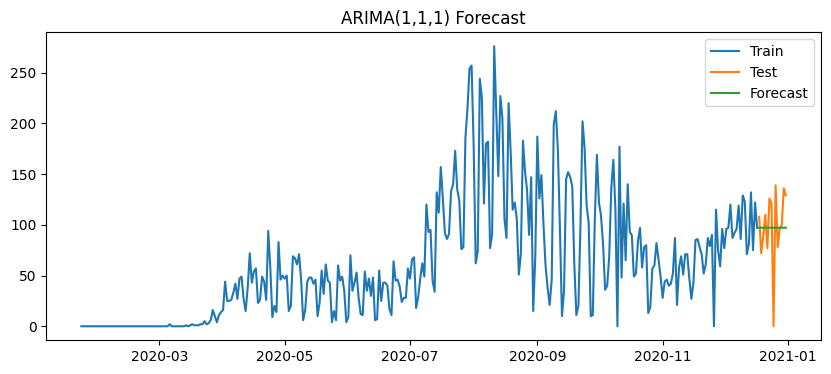

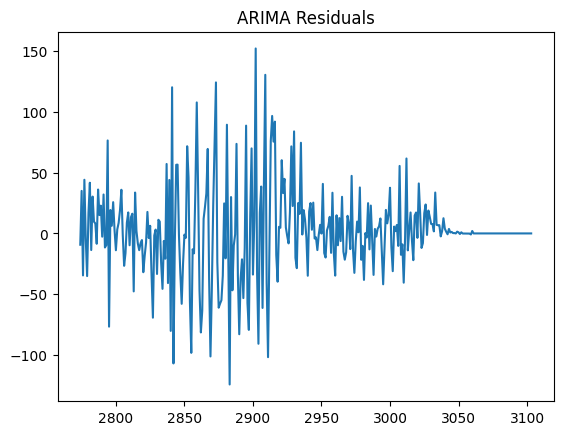

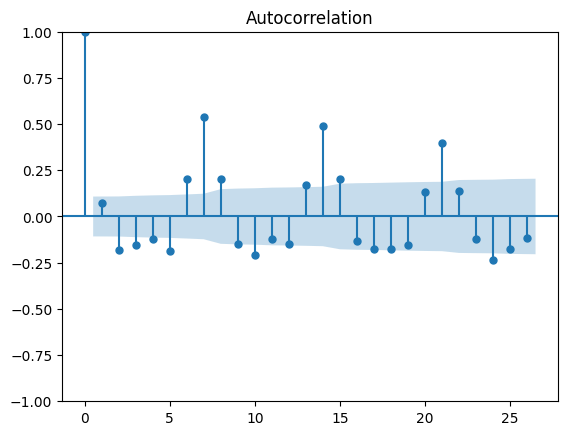

ARIMA → MAE: 25.91, RMSE: 34.72


In [ ]:
# ARIMA(p,d,q)
model_arima = ARIMA(train['Y.Death'], order=(1,1,1)).fit()

forecast_arima = model_arima.forecast(14)

plot_forecast(train, test, forecast_arima, "ARIMA(1,1,1) Forecast")

# Residuals
residuals = model_arima.resid

plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.show()

plot_acf(residuals)
plt.show()

evaluate_model(test['Y.Death'], forecast_arima, "ARIMA")

## 6. SARIMA Model

### Model

$(1-B)^d (1-B^s)^D X_t = ARMA%

---

### Meaning

- \(s\): seasonal period  
- \(D\): seasonal differencing  

---

### Interpretation (Fig 9.21)

Captures weekly structure  

---

### Advantage
- Handles seasonality  

### Disadvantage
- Complex  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

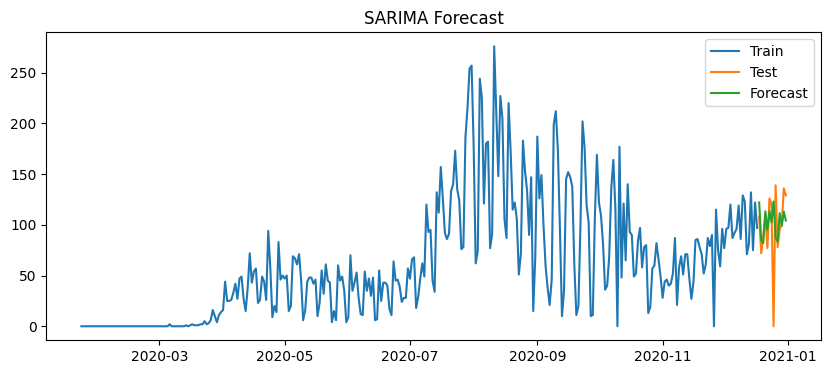

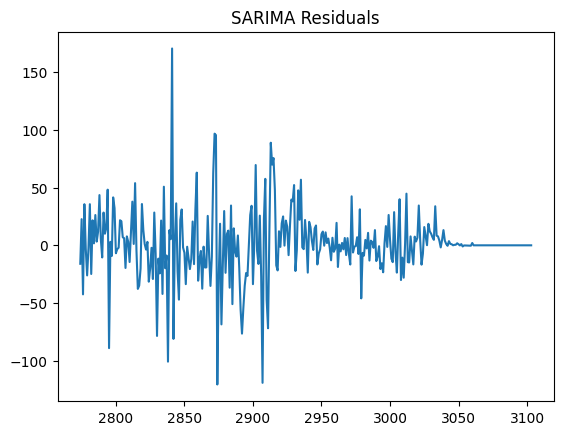

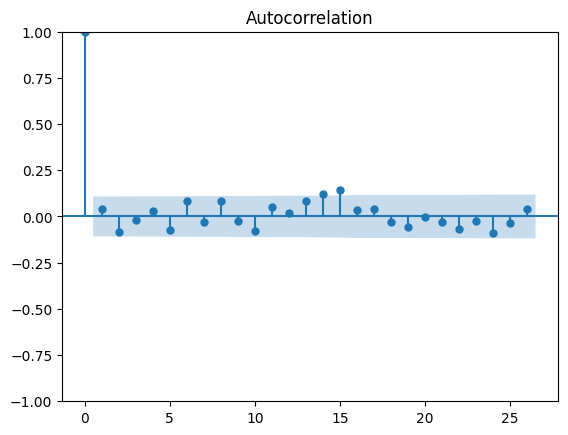

SARIMA → MAE: 23.57, RMSE: 38.20


In [ ]:
# SARIMA(p,d,q)(P,D,Q)s
model_sarima = ARIMA(
    train['Y.Death'],
    order=(1,0,1),
    seasonal_order=(1,1,1,7)
).fit()

forecast_sarima = model_sarima.forecast(14)

plot_forecast(train, test, forecast_sarima, "SARIMA Forecast")

# Residuals
residuals = model_sarima.resid

plt.plot(residuals)
plt.title("SARIMA Residuals")
plt.show()

plot_acf(residuals)
plt.show()

evaluate_model(test['Y.Death'], forecast_sarima, "SARIMA")

## 6. Exponential Smoothing (ETS)

### Why?

- Moving average gives equal weights
- ETS gives **more weight to recent data**

---

### Formula

$\hat{m}_t = \alpha Y_t + (1-\alpha)\hat{m}_{t-1}$

---

### Intuition

- α close to 1 → reacts quickly
- α small → smoother

---

### Advantages
- Adaptive
- Good for real-time forecasting

### Limitations
- Assumes simple structure

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


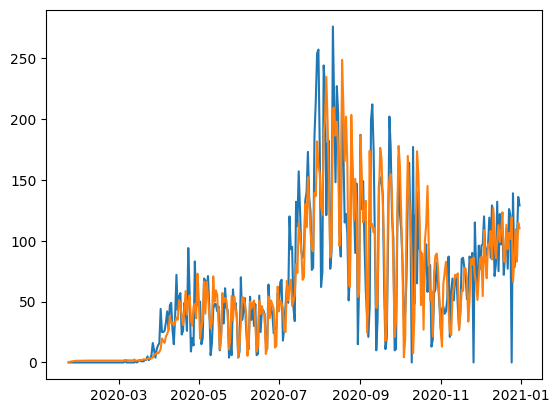

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ets_model = ExponentialSmoothing(
    florida['Y.Death'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

florida['ETS'] = ets_model.fittedvalues

plt.figure()
plt.plot(florida['DATE'], florida['Y.Death'])
plt.plot(florida['DATE'], florida['ETS'])
plt.show()

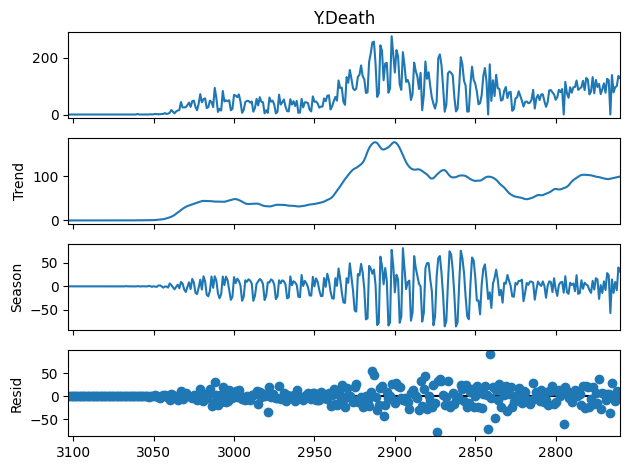

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(florida['Y.Death'], period=7)
res = stl.fit()

res.plot()
plt.show()

## 8. Residual Diagnostics

### Why?

To check if model captured all information.

---

### Good Residual Properties
- Mean ≈ 0
- No autocorrelation
- Constant variance
- Normal distribution

---

### If violated → model is incomplete

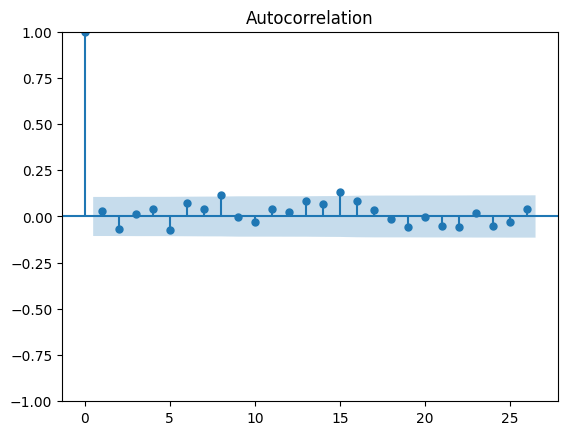

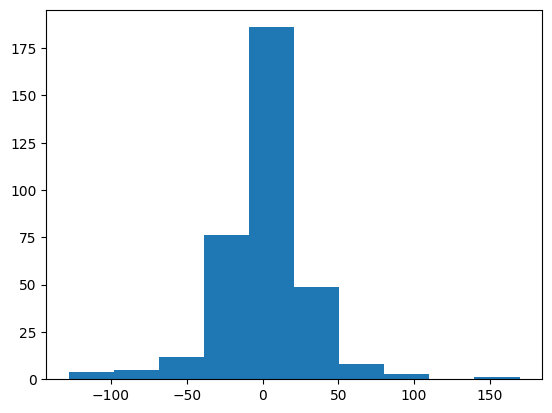

In [ ]:
residuals = florida['Y.Death'] - florida['ETS']

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals)
plt.show()

plt.hist(residuals)
plt.show()

## 9. ARIMA Models

### Why?

Captures **time dependence (autocorrelation)**.

---

### Model

$(1-B)^d Y_t = ARMA(p,q)$

---

### Intuition

- AR → depends on past values
- MA → depends on past errors

---

### Advantages
- Powerful for correlated data
- Handles non-stationarity

### Limitation
- Requires tuning

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model_arima = ARIMA(florida['Y.Death'], order=(1,1,1)).fit()

forecast_arima = model_arima.forecast(14)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s